# Machine Learning Explainability

This project focuses on using the ELI5, LIME, and SHAP libraries to explain local and global predictions of classifiers trained to predict death in patients with heart disease. Each explainability technique is used to showcase methods for understanding how models make their predictions and is compared with the class probability estimates in order to gauge how effective and trustworthy each model is.

# Library Imports

In [1]:
# Suppress warnings
import warnings
warnings.filterwarnings("ignore")

import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# Custom functions for loading and saving objects
from modules.io_utils import load_object, save_object

# Custom functions for preprocessing and encoding data
from modules.preprocessing import convert_column_names_and_types, decode_data, encode_features

# Custom functions for plotting
from modules.plotting import (
    association_heatmap,
    correlation_heatmap,
    eli5_global_feature_plot,
    eli5_local_prediction_explanations,
    plot_confusion_matrix,
    plot_local_lime_explanations,
    shap_force_plot,
    shap_waterfall_plot,
    style_model_metrics
)

# Custom functions for statistical calculations
from modules.statistics import calculate_VIF

# Custom functions for training and scoring
from modules.training import fit_model, get_model_predictions_and_scores

2025-12-15 00:37:47.577031: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765777067.599690   37810 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765777067.604313   37810 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1765777067.620272   37810 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765777067.620301   37810 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1765777067.620303   37810 computation_placer.cc:177] computation placer alr

# Load and Clean Data

In [2]:
# Read data
df = pd.read_csv('../data/heart_failure_clinical_records_dataset.csv')
df

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,270,0
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,271,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,278,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1,280,0


There are no missing, null, or placeholder values. Each column was inspected for errors: Age and Platelets should both be integer columns, and Anaemia, High Blood Pressure, Diabetes, Sex, and Smoking are all binary flag columns. DEATH_EVENT should be converted to a lower case name to follow the other column naming conventions.

Otherwise, the data is exceptionally clean and requires no further processing.

In [3]:
# Inspect data types and null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


Columns are converted as needed, and the target is renamed to "death".

In [4]:
# Convert column names and data types
df = convert_column_names_and_types(
    df = df,
    target = 'DEATH_EVENT',
    int_columns = ['age', 'platelets'],
    binary_columns = [
        'anaemia', 'high_blood_pressure', 'diabetes', 'sex', 'smoking'
    ]
)

# EDA

Age ranges from 40-95, with an average age of 60 years, indicating most patients are middle-aged to elderly. Creatinine Phosphokinase ranges from 23 to 7861, while the normal adult range is about 10-120 mcg/L. Ejection Fraction ranges from 14%-80%, with an average of 38%, while typical healthy ranges are between 50%-70%. Platelets range from 25,100 to 850,000, while normal health adults have ranges betwen 150,000-450,000/mcL. Serum creatinine ranges are between 0.5 and 9.4, with normal ranges lying between 0.6-1.2 mg/dL. Serum Sodium ranges from 113-148, with typical healthy levels lying between 135-145 mEq/L.

No transformations need to be done to this data, but it is worth recognizing that this dataset is biased towards older patients with higher risk of heart failure. This means that there is not a good set of "normal" data comprised of younger humans with healthier bioinformatics to compare against.

In [5]:
# Descriptive statistics for the numeric values
df.describe()

,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,time,death
count,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000
mean,60.829431,581.839465,38.083612,263358.026756,1.39388,136.625418,130.260870,0.32107
std,11.894997,970.287881,11.834841,97804.236869,1.03451,4.412477,77.614208,0.46767
min,40.000000,23.000000,14.000000,25100.000000,0.50000,113.000000,4.000000,0.00000
25%,51.000000,116.500000,30.000000,212500.000000,0.90000,134.000000,73.000000,0.00000
50%,60.000000,250.000000,38.000000,262000.000000,1.10000,137.000000,115.000000,0.00000
75%,70.000000,582.000000,45.000000,303500.000000,1.40000,140.000000,203.000000,1.00000
max,95.000000,7861.000000,80.000000,850000.000000,9.40000,148.000000,285.000000,1.00000


Although the target variable is binary, we can use point biserial correlation to compare continuous variables to a binary variable. The point biserial correlation uses the same formula as Pearson correlation, as long as the binary variable is encoded as 0/1.

Age and Serum Creatinine are somewhat correlated with the target (Death), indicating that older patients and those with higher creatinine are at higher risk of death, which makes sense from a domain perspective. Surprisingly, Serum Sodium is negatively correlated with death, indicating higher concentrations of sodium in the blood are less likely to result in death. Ejection Fraction is negatively correlated with death, as a higher percentage of blood leaving the heart at each contraction indicates a stronger heart muscle which usually means a healthier heart. However, it should be noted that a consistently high Ejection Fraction is associated with heart conditions.

Time is moderately negatively correlated with death, which makes sense since if a doctor prescribes a longer follow-up period / a patient chooses not to pursue a follow-up immediately, it likely indicates that the doctor thinks the patient is not at high risk or that the patient is not experiencing any symptoms that makes them seek medical attention.

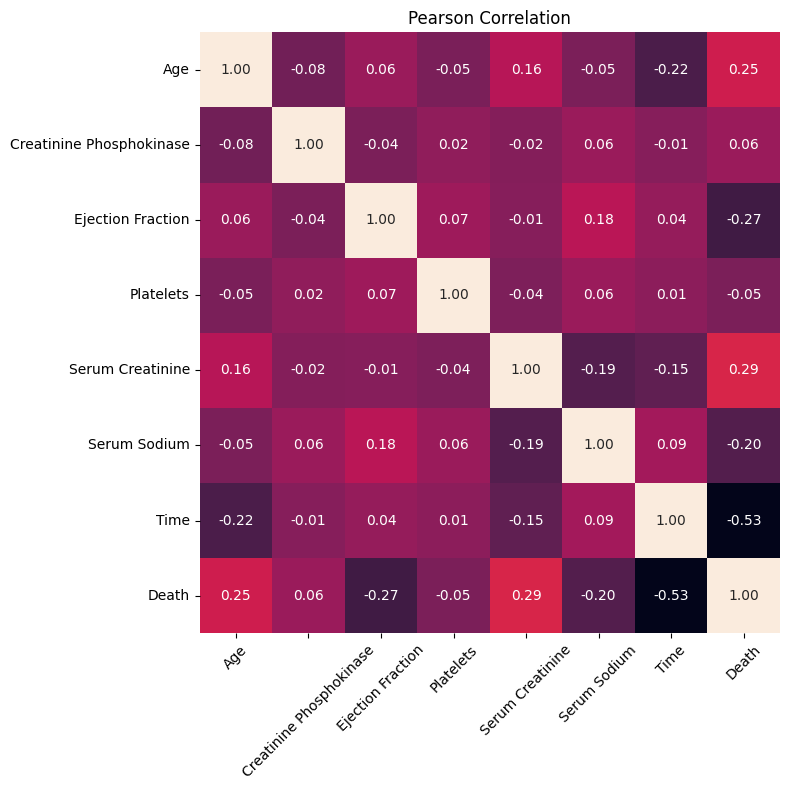

In [6]:
# Pearson correlation heatmap
correlation_heatmap(df, abs = False, figsize = (8, 8));

The Variance Inflation Factor (VIF) is used to check for multicollinearity among numeric variables. VIF values greater than 4 indicate the presence of multicollinearity, and VIF values greater than 10 indicate severe multicollinearity. Since all of the VIF values are below 4, there is no multicollinearity in our numeric features, indicating that the features contain no redundant information.

In [7]:
# Variance inflation factor for multicollinearity
calculate_VIF(df)

age                         1.119431
creatinine_phosphokinase    1.021446
ejection_fraction           1.143718
platelets                   1.012026
serum_creatinine            1.135647
serum_sodium                1.090252
time                        1.419699
death                       1.699468
Name: VIF, dtype: float64

Cramer's V statistic is used to measure the effect strength of association between two categorical variables and is based off of the $\chi^2$ statistic. Cramer's V lies between 0 and 1, with values near 1 indicating high association and values near 0 indicating no association.

Since all of the categorical variables in the dataset are binary, Cramer's V interpretation is as follows: $0.1 \leq V \leq 0.3$ equals weak association, $0.3 \leq V \leq 0.5$ equals moderate association, and $V \geq 0.5$ equals strong association. None of the categorical variables are even weakly associated with the target (Death). Sex is moderately associated with Smoking and is weakly associated with Diabetes and High Blood Pressure. Anaemia and Diabetes are also weakly associated with Smoking.

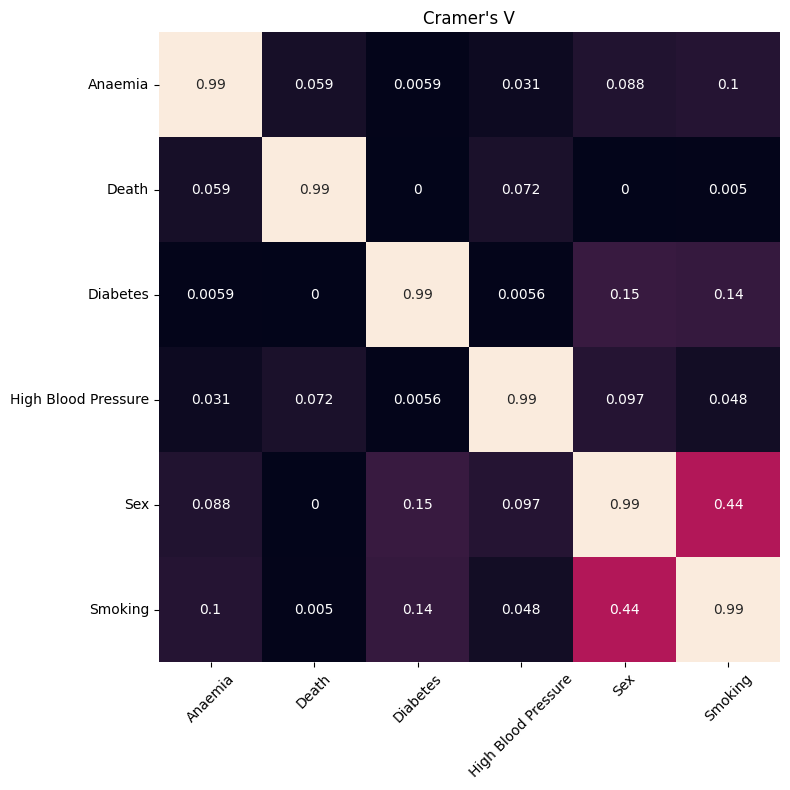

In [8]:
# Cramer's V association heatmap
association_heatmap(pd.concat([df.select_dtypes(['object', 'category']), df['death']], axis = 1), figsize = (8, 8));

# Data Preparation and Encoding

Notice that the target variable (death) is imbalanced. This means the data should be stratified to keep class proportions equal across train and test data.

In [9]:
# Value counts for target variable - note that classes are imbalanced
df.death.value_counts(normalize = True)

death
0    0.67893
1    0.32107
Name: proportion, dtype: float64

Because each of the categorical variables is already encoded as a binary flag, they do not need to be encoded.

Numeric features will be standardized to bring features within similar ranges which is important for the Logistic Regression and XGBoost models.

The data will be split into 75%/25% for training and test, stratified along the target variable to preserve class proportions.

In [10]:
# Split data into independent features and target
X = df.drop(['death'], axis = 1)
y = df['death']

# Encode features
train, test, encoder = encode_features(
    X = X,
    y = y,
    numeric_cols = X.select_dtypes('number').columns,
    passthrough_cols = X.select_dtypes(['object', 'category']).columns,
    test_size = 0.25,
    random_state = 42
)

In [11]:
# Save encoded datasets for later use
train.to_csv('../data/heart_failure_train.csv', index = False)
test.to_csv('../data/heart_failure_test.csv', index = False)

# Save preprocessor for futher use in converting data back to original scalings
save_object(encoder, '../models/preprocessor', compression = 'lzma')

Successfully saved object to ../models/preprocessor.pickle.xz


# Model Training and Tuning

In [12]:
# Load training and test data
train = pd.read_csv('../data/heart_failure_train.csv')
X_train = train.iloc[:, :-1]
y_train = train.iloc[:, -1]

test = pd.read_csv('../data/heart_failure_test.csv')
X_test = test.iloc[:, :-1]
y_test = test.iloc[:, -1]

The base models are defined below. Random state is fixed at 42 for reproducibility, and n_jobs is set at -1 for maximum training speed. The Logistic Regression requires a higher max iteration count to ensure convergence. The Saga solver is used over the default LBFGS solver in order to allow the use of both L1 and L2 penalties.

In [13]:
# Define base models
base_logreg = LogisticRegression(
    random_state = 42, solver = 'saga', max_iter = 3000, n_jobs = -1 # Saga solver for use of L1 and L2 penalties
)
base_dt = DecisionTreeClassifier(random_state = 42)
base_rf = RandomForestClassifier(random_state = 42, n_jobs = -1)
base_xgb = XGBClassifier(random_state = 42, n_jobs = -1)

Each of the following grids is designed to help reduce overfitting and improve model generalization. Because the dataset is so small, overfitting is more likely due to lack of training samples. However, since the dataset is so small, it is possible to perform an exhaustive grid search over fairly large grids since training time is short. A brief description of the hyperparameters chosen is given below:

- Logistic Regression: Choice and strength of regularization to remove redundant or irrelevant features.
- Decision Tree: Restriction of max depth and minimum samples in leaf forces trees to not grow until fully pure, thus not fitting the data as tightly. Restricting the max features used for each split can also reduce overfitting by not always choosing the exact best feature for splitting and allowing for the exploration of "suboptimal" splits.
- Random Forest: Effectively the same logic as the Decision Tree. A higher number of estimators can reduce variance at the cost of model complexity.
- XGBoost: The number of boosting rounds determines how long training continues. Restricting max depth creates weaker learners so that each learner fits less tightly to the data. Subsample restricts the number of samples used for each tree, preventing each learner from seeing the entire dataset. Colsample restricts the number of features for each tree. Alpha and Lambda are regularization terms on weights that help remove redundant or irrelevant features.

In [14]:
# Define paramater grids
logreg_grid = {
    'logreg__penalty': ['l1', 'l2'],             # Regularization penalty type
    'logreg__C': [10**i for i in range(-3, 4)]   # Regularization strength
}

dt_grid = {
    'dt__max_depth': [None, 5, 7, 9, 11],        # Maximum depth of the tree
    'dt__min_samples_leaf': [1, 10, 20, 40],     # Minimum number of samples required to be at a leaf node
    'dt__max_features': [None, 0.25, 0.5],       # Number of features to consider when looking for the best split
}

rf_grid = {
    'rf__n_estimators': [100, 200],              # Number of trees to use
    'rf__max_depth': [None, 5, 7, 9, 11],        # Max depth of each tree
    'rf__max_features': [None, 0.25, 0.5],       # Number of features to consider when looking for the best split
    'rf__min_samples_leaf': [1, 10, 20, 40],     # Minimum number of samples required to be at a leaf node
}

xgb_grid = {
    'xgb__n_estimators': [100, 200, 400],        # Number of boosting rounds
    'xgb__max_depth': [3, 5, 7],                 # Maximum depth of a tree
    'xgb__subsample': [0.8, 0.9, 1.0],           # Subsample ratio of the training instance
    'xgb__colsample_bytree': [0.8, 0.9, 1.0],    # Subsample ratio of columns when constructing each tree
    'xgb__reg_alpha': [0, 0.1, 0.5],             # L1 regularization term on weights
    'xgb__reg_lambda': [1, 1.5, 2]               # L2 regularization term on weights
}

In [15]:
# Wrap model names, base classifiers, and their corresponding grids
# Model identifiers
models = ['logreg', 'dt', 'rf', 'xgb']

# Base classifier instances (aligned with model names)
base_estimators = [base_logreg, base_dt, base_rf, base_xgb]

# Hyperparameter grids for each model
grids = [logreg_grid, dt_grid, rf_grid, xgb_grid]

# Combine model name, estimator, and grid into a single iterable
model_grids = list(zip(models, base_estimators, grids))

# Define directory for saving trained models and metrics
model_dir = '../models'
metrics_dir = '../metrics'

Because the target variable is imbalanced, accuracy is a poor metric for training. Recall is arguably more important than precision for this dataset, as it is best to successfully capture those at risk of death in order to prevent deaths at the cost of false positives, which results in wasted tests but fewer deaths overall.

However, training models to focus only on recall has a tendency to produce "dumb" models which always predict that the event will occur. Thus, to maintain a balance between precision and recall, average precision score (equivalent to area under the precision recall curve) is used as the scoring metric for hyperparameter tuning. Average precision score optimizes models to be as robust as possible by minimizing the precision-recall tradeoff along as many decision thresholds as possible.

In [16]:
# Train and hyperparameter-tune models for each dataset
for model_name, base_estimator, grid in model_grids:
    print(f'Training base model for {model_name.upper()}.')
    # Fit gridsearch model with 5-fold cross-validation and save results
    fit_model(
        X_train = X_train,
        y_train = y_train,
        model_name = model_name,
        model = base_estimator,
        scoring = 'average_precision',
        grid_search = True,
        param_grid = grid,
        cv = 5,
        save = True,
        save_path = os.path.join(model_dir, f'{model_name}'),
        compression = 'lzma'
    )

Training base model for LOGREG.
Fitting 5 folds for each of 14 candidates, totalling 70 fits
Successfully saved object to ../models/logreg.pickle.xz
Training base model for DT.
Fitting 5 folds for each of 60 candidates, totalling 300 fits
Successfully saved object to ../models/dt.pickle.xz
Training base model for RF.
Fitting 5 folds for each of 120 candidates, totalling 600 fits
Successfully saved object to ../models/rf.pickle.xz
Training base model for XGB.
Fitting 5 folds for each of 729 candidates, totalling 3645 fits
Successfully saved object to ../models/xgb.pickle.xz


Predictions and probabilities are generated using model.predict() and model.predict_proba(), respectively. These predictions and probabilities are gathered, along with the ground-truth labels from the test set into a file "model_predictions.csv" placed into the metrics directory. The following scores are calculated for each model: Accuracy, Recall, Precision, F1-Score, and Average Precision (PR AUC). These scores are collected and placed into a file "model_metrics.csv" within the metrics directory.

In [17]:
# Create predictions and calculate scoring metrics on test set
get_model_predictions_and_scores(
    X = X_test,
    y = y_test,
    model_dir = model_dir,
    metrics_dir = metrics_dir,
    model_types = models
);

Successfully loaded object from ../models/logreg.pickle.xz
Successfully loaded object from ../models/dt.pickle.xz
Successfully loaded object from ../models/rf.pickle.xz
Successfully loaded object from ../models/xgb.pickle.xz


# Model Performance

In [18]:
# Load model predictions and metrics
predictions = pd.read_csv('../metrics/model_predictions.csv')
metrics = pd.read_csv('../metrics/model_metrics.csv')

# Define model types and model dir
models = ['logreg', 'dt', 'rf', 'xgb']
model_dir = '../models'

# Load encoder
encoder = load_object('../models/preprocessor.pickle.xz')

# Load training and test data
train = pd.read_csv('../data/heart_failure_train.csv')
X_train = train.iloc[:, :-1]
y_train = train.iloc[:, -1]

test = pd.read_csv('../data/heart_failure_test.csv')
X_test = test.iloc[:, :-1]
y_test = test.iloc[:, -1]

# Decode training and testing data
X_train_decoded = decode_data(X = X_train, encoder = encoder)
X_test_decoded = decode_data(X = X_test, encoder = encoder)

Successfully loaded object from ../models/preprocessor.pickle.xz


The XGBoost model has the highest Accuracy, Recall, and F1-Score. Because we value Recall slightly higher than Precision for this dataset, this makes the XGBoost model the best model. However, the Random Forest outperforms the XGBoost in Precision and Average Precision (PR AUC). This means that the Random Forest is likely a bit more robust but is less able to capture actual death events at default thresholding. The Logistic Regression and Decision Tree models are less complex and are also less performant, illustrating the tradeoff between model complexity, performance, and interpretability.

Since capturing actual deaths, or at least capturing the risk of death, is important for the practical usage of these models, the Random Forest is less preferable compared to the XGBoost. Slightly lower Precision is more acceptable than lower Recall for the real-world use of this data.

In [19]:
# Model metrics with max values for each metric highlighted
style_model_metrics(metrics)

,Logistic Regression,Decision Tree,Random Forest,XGBoost
Accuracy,0.813333,0.800000,0.853333,0.866667
Precision,0.812500,0.695652,0.933333,0.888889
Recall,0.541667,0.666667,0.583333,0.666667
F1 Score,0.650000,0.680851,0.717949,0.761905
Average Precision (PR AUC),0.750490,0.763446,0.846441,0.827748


The False Positives are located on the upper right quadrant, while the False Negatives are located on the lower left quadrant. It is worth recognizing that despite the XGBoost model having worse precision, it only has 1 more False Positive than the Random Forest while having two fewer False Negatives. This shows that the XGBoost model has the best predictive power for the purposes of this dataset.

The Decision Tree is very imprecise, while the Logistic Regression has poor recall.

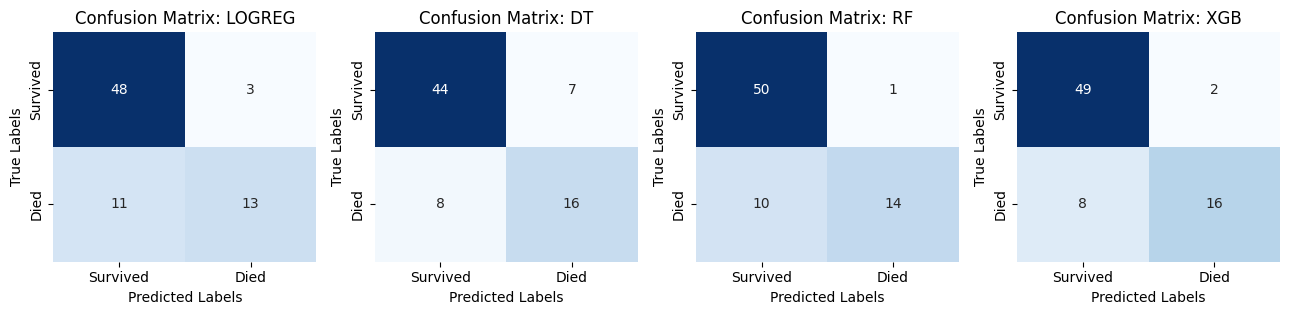

In [20]:
# Confusion matrices for each model
fig, axes = plt.subplots(1, 4, figsize = (13, 3.25), sharey = False)

for ax, model in zip(axes, models):
    plot_confusion_matrix(
        prediction_frame = predictions,
        model = model,
        ax = ax
    );

plt.tight_layout();

# Explainability Analysis

The following prediction candidate indices will be viewed more closely for each model type, based on how well the model predicted (for true positive/negative) or how poorly the model failed to predict each candidate (for false positive/negative).

True Positive / True Negative / False Positive / False Negative:
- Logistic Regression: 11, 4, 3, 68
- Decision Tree: 11, 4, 19, 5
- Random Forest: 11, 4, 57, 73
- XGBoost: 73, 4, 53, 61

## ELI5 Logistic Regression and Decision Tree

The ELI5 package as used for this project extracts the model coefficients (for Logistic Regression) or node splitting (for Decision Tree). These are glass-box models and the ELI5 package simply helps wrangle the code without requiring the user to dive into the objects' properties themselves.

Note that the ELI5 default plots are nearly impossible to read when using a dark mode theme. The outputs have been converted to Matplotlib plots for readability.

### Logistic Regression

In [21]:
# Logistic Regression prediction indices
logreg_idx = [11, 4, 3, 68]

The weights for the logistic regression show that Serum Creatinine and Time are the most influential features, followed by Ejection Fraction. Age has low weight, while all other features have coefficient zero due to model regularization. This aligns closely with the patterns found during EDA.

Successfully loaded object from ../models/logreg.pickle.xz


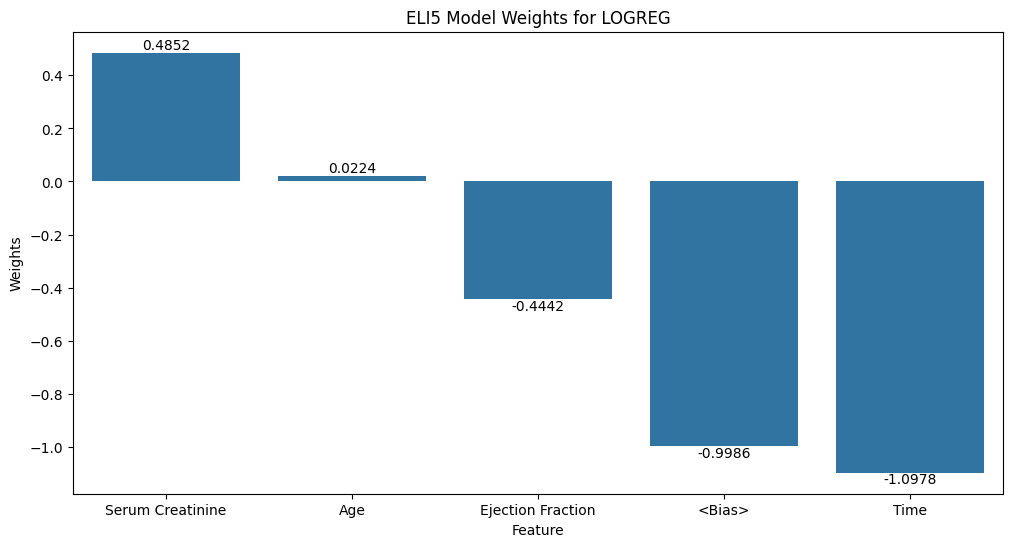

In [22]:
# Global feature coefficients for logistic regression
eli5_global_feature_plot(
    model_type = 'logreg',
    model_dir = model_dir,
    feature_names = X_test.columns.tolist()
);

For the True Positive prediction, the Logistic Regression model relied mainly on Time and Ejection Fraction. For the True Negative prediction, Time was the main factor, with smaller influence from Serum Creatinine and Ejection fraction. The False Positive prediction was overly influenced by the Serum Creatinine, while the False Negative prediction was heavily influenced by both Time and Ejection Fraction.

Successfully loaded object from ../models/logreg.pickle.xz


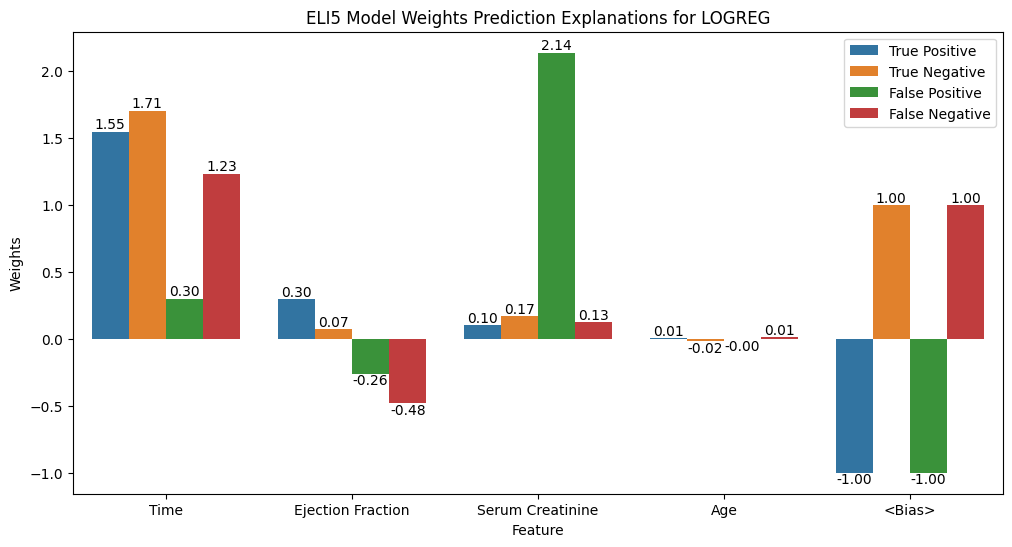

In [23]:
# Local prediction explanations
eli5_local_prediction_explanations(
    model_type = 'logreg',
    model_dir = model_dir,
    X_test = X_test,
    model_idx = logreg_idx
);

The False Positive had an exceptionally high Serum Creatinine value, causing the model to be confident that the patient had died despite a moderately high Ejection Fraction value which are normally indicators of patient health. The False Negative was influenced by a low Serum Creatinine Value (an indicator of good patient health) as well as a high Time value (low patient risk) despite the low Ejection Fraction value (normally an indicator of poor patient health).

In [24]:
# X_test feature values for logistic regression indices
X_test_decoded.iloc[logreg_idx]

,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,time,anaemia,diabetes,high_blood_pressure,sex,smoking
11,65,128,30,297000,1.6,136,20,1,1,1,0,0
4,70,2695,40,241000,1.0,137,247,0,1,0,1,0
3,60,1082,45,250000,6.1,131,107,1,1,0,1,0
68,55,2017,25,314000,1.1,138,214,0,0,0,1,0


The Logistic Regression model was highly confident in its predictions for each of these instances.

In [25]:
# Predictions for logistic regression indices
predictions.iloc[logreg_idx]

,logreg-predictions,logreg-probabilities,dt-predictions,dt-probabilities,rf-predictions,rf-probabilities,xgb-predictions,xgb-probabilities,ground_truth
11,1,0.721291,1,1.000000,1,0.644077,1,0.840203,1
4,0,0.050647,0,0.100000,0,0.110567,0,0.002562,0
3,1,0.764429,1,0.631579,0,0.399150,0,0.396919,0
68,0,0.131443,0,0.312500,0,0.306255,0,0.013380,1


### Decision Tree

In [26]:
# Decision Tree prediction indices
dt_idx = [11, 4, 19, 5]

The feature importances for the Decision Tree show that Time had the highest importance. Serum Creatinine, Serum Sodium, and Ejection Fraction followed with much lower importance, with Platelets and Creatinine Phosphokinase having minimal importance. These match with the expectations from EDA and notably captures Serum Sodium which the Logistic Regression did not capture. Surprisingly, Age appears to play no importance in the Decision Tree model, which seems incorrect. Time having such large importance matches with the EDA but is a little puzzling logically. Time to follow up is not directly an indicator of patient health, although it may be a proxy for the doctor's diagnosis of patient risk.

Successfully loaded object from ../models/dt.pickle.xz


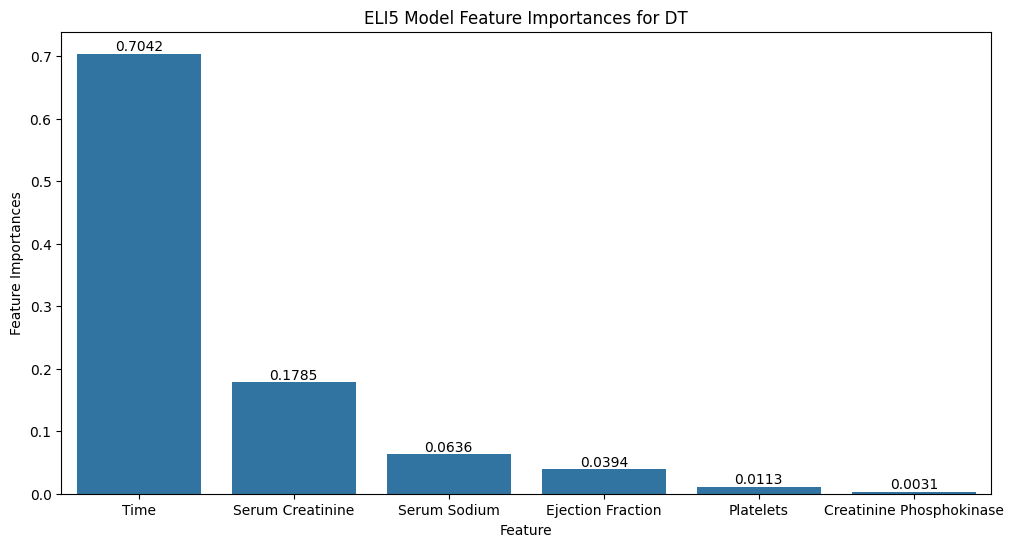

In [27]:
# Global feature coefficients for decision tree
eli5_global_feature_plot(
    model_type = 'dt',
    model_dir = model_dir,
    feature_names = X_test.columns.tolist()
);

For the True Positive prediction, the Decision Tree model relied mainly on Time, Serum Sodium, and Serum Creatinine. For the True Negative prediction, most of the features were used, with particular emphasis on Creatinine Phosphokinase. The False Positive prediction was overly influenced by the Serum Sodium and Time, while the False Negative prediction was heavily influenced by Serum Creatinine and Ejection Fraction.

Note that Bias is simply the proportion of class presence (68% negative class, 32% positive class).

Successfully loaded object from ../models/dt.pickle.xz


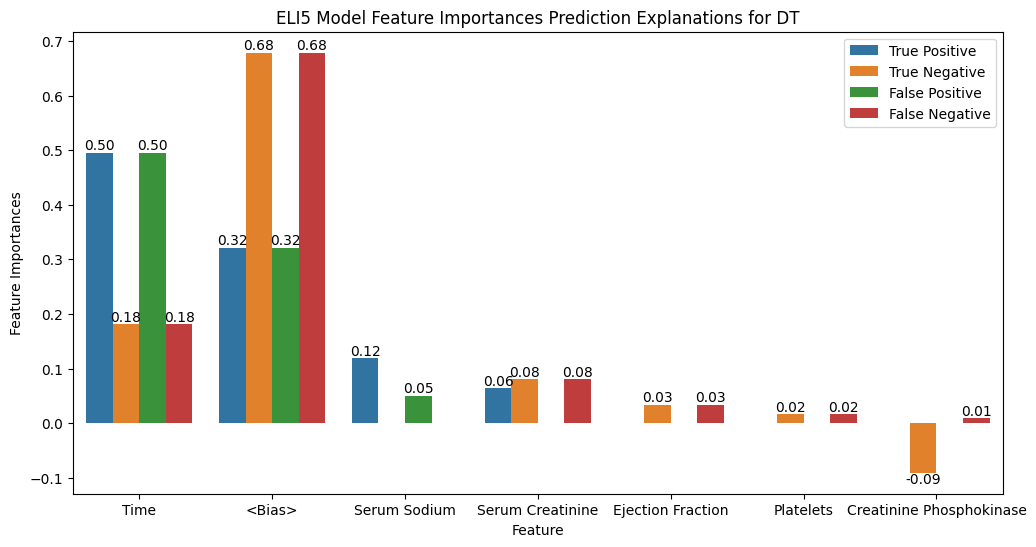

In [28]:
# Local prediction explanations
eli5_local_prediction_explanations(
    model_type = 'dt',
    model_dir = model_dir,
    X_test = X_test,
    model_idx = dt_idx
);

The False Positive had a low Time value (implying high health risk) and was flagged due to Serum Sodium level, even though this level of Serum Sodium is typically considered normal, causing the model to be confident that the patient had died despite a low Serum Creatinine value and a relatively low Age value, which was ignored by the Decision Tree model. The False Negative was influenced by the very high Ejection Fraction (normally an indicator of good patient health) and low Serum Creatinine, despite a high Age value and Platelet count which are indicative of heart attack risks. These results highlight the downside of the Decision Tree ignoring the Age feature and the lack of a set of "healthy" individuals to compare against while training.

In [29]:
# X_test feature values for decision tree indices
X_test_decoded.iloc[dt_idx]

,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,time,anaemia,diabetes,high_blood_pressure,sex,smoking
11,65,128,30,297000,1.6,136,20,1,1,1,0,0
4,70,2695,40,241000,1.0,137,247,0,1,0,1,0
19,55,109,35,254000,1.1,139,60,0,0,0,1,1
5,70,143,60,351000,1.3,137,90,1,0,0,0,0


The Decision Tree model was exceedingly confident in its predictions for each of these instances, indicating overconfidence.

In [30]:
# Predictions for decision tree indices
predictions.iloc[dt_idx]

,logreg-predictions,logreg-probabilities,dt-predictions,dt-probabilities,rf-predictions,rf-probabilities,xgb-predictions,xgb-probabilities,ground_truth
11,1,0.721291,1,1.000000,1,0.644077,1,0.840203,1
4,0,0.050647,0,0.100000,0,0.110567,0,0.002562,0
19,0,0.486903,1,0.866667,0,0.492904,0,0.123318,0
5,0,0.216569,0,0.000000,0,0.181509,0,0.001694,1


## LIME Random Forest and XGBoost

Local Interpretable Model-agnostic Explanations (LIME) is a machine learning explainability technique used to explain black-box models. LIME only works at the local level for individual predictions. For tabular data, LIME attempts to approximate the model by fitting a linear model around the data point by sampling points randomly around the prediction. The distance of sampled points is decided by the kernel width, with larger widths becoming similar to a linear global approximation (which is obviously poor for any non-linear model) and smaller widths representing just the point itself with no feature relevance.

An issue with LIME is that the local surrogte model may be very poor depending on kernel width. By default, LIME uses an exponential kernel with width equal to 0.75 times the square root of the number of features, but there is no reason that this kernel is optimal or even good for any given dataset. LIME is also highly susceptible to the curse of dimensionality and to differences in distances across dimensions (features). LIME results can change dramatically depending on kernel width selection, making results difficult to trust and interpret, with no clear guidelines on how to choose the best kernel width.

The default LIME display for notebooks is difficult to read when using a dark mode theme. The outputs have been converted to Matplotlib plots for readability.

### Random Forest

In [31]:
# Random Forest prediction indices
rf_idx = [11, 4, 57, 73]

The True Positive prediction for the Random Forest is mainly governed by a low Time value, as well as slightly elevated Serum Creatinine and lower Ejection Fraction, which are all indicators of poor health. It is worth noting that the Random Forest was not highly confident that the True Positive was a True Positive. The False Positive prediction was strongly influenced by the same Time and Ejection Fraction factors.

Both the True Negative and False Negative predictions have extremely low $R^2$ scores, indicating that the LIME approximations for these predictions is of low quality. The features driving the True Negative prediction do make sense; high Time values, higher than average Ejection Fraction (although still lower than a normal healthy heart), and lower than average Serum Creatinine all imply a healthier patient.

The negative predictions have low $R^2$ values because of the highly positive intercept, making it hard for the local approximation to predict class 0, as predictions are naturally pulled towards class 1. The Random Forest model must be creating a complex boundary for a local linear approximation to perform so poorly.

Successfully loaded object from ../models/rf.pickle.xz


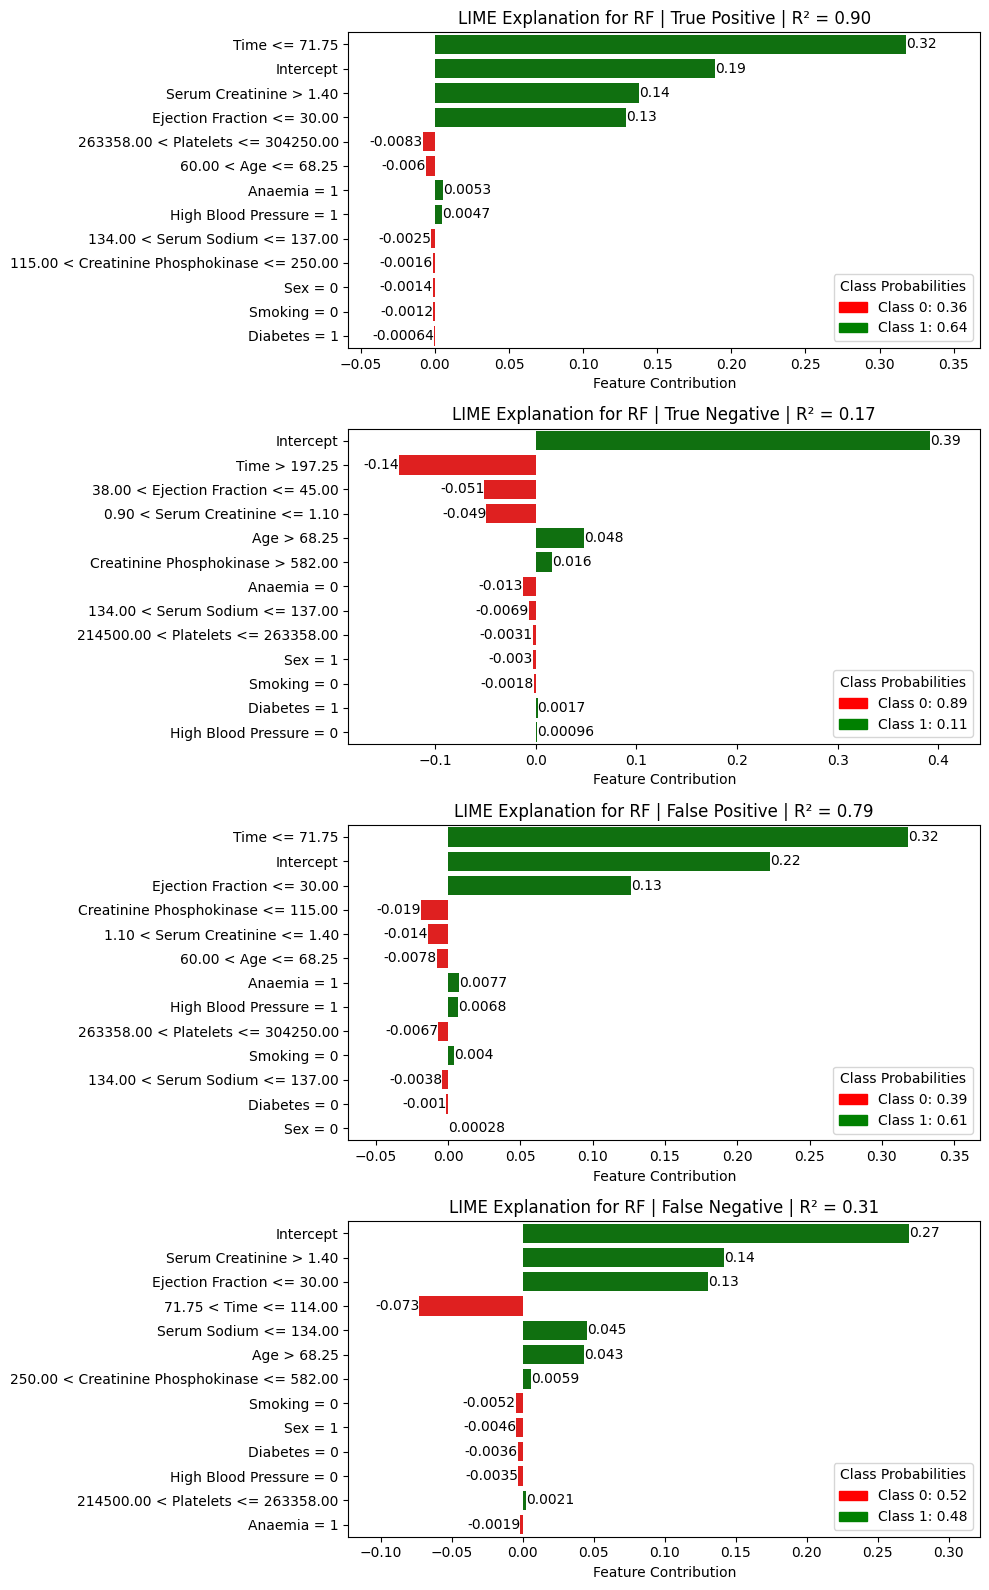

In [32]:
# LIME explanations for local predictions on Random Forest
plot_local_lime_explanations(
    model_type = 'rf',
    model_dir = model_dir,
    X_train = X_train_decoded,
    X_test = X_test_decoded,
    model_idx = rf_idx,
    categorical_features = [7, 8, 9, 10, 11]
);

The False Positive had a very low Ejection Fraction value, indicating poor heart health, and a low Time value, indicating high health risk. The False Negative is puzzling since the high Age value, low Ejection Fraction value, slightly elevated Serum Creatinine, and lower Time value should all have contributed to poor patient health and high health risk, yet the model predicted this as a negative. It is worth noting that the Random Forest barely predicted the False Negative as a Negative.

In [33]:
# X_test feature values for random forest indices
X_test_decoded.iloc[rf_idx]

,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,time,anaemia,diabetes,high_blood_pressure,sex,smoking
11,65,128,30,297000,1.60,136,20,1,1,1,0,0
4,70,2695,40,241000,1.00,137,247,0,1,0,1,0
57,65,52,25,276000,1.30,137,16,1,0,1,0,0
73,75,582,30,225000,1.83,134,113,1,0,0,1,0


It is worth noting that for the selected predictions, the Random Forest was not very confident in its predictions, except for the True Negative.

In [34]:
load_object('../models/rf.pickle.xz').predict_proba(X_test.iloc[[rf_idx[0]]])

Successfully loaded object from ../models/rf.pickle.xz


array([[0.35592307, 0.64407693]])

In [35]:
# Predictions for random forest indices
predictions.iloc[rf_idx]

,logreg-predictions,logreg-probabilities,dt-predictions,dt-probabilities,rf-predictions,rf-probabilities,xgb-predictions,xgb-probabilities,ground_truth
11,1,0.721291,1,1.000000,1,0.644077,1,0.840203,1
4,0,0.050647,0,0.100000,0,0.110567,0,0.002562,0
57,1,0.742143,0,0.500000,1,0.614522,1,0.903632,0
73,0,0.436030,1,0.631579,0,0.484976,1,0.735139,1


### XGBoost

In [36]:
# XGBoost prediction indices
xgb_idx = [73, 4, 53, 61]

The XGBoost model is even more complex than the Random Forest, and as such, the LIME explanations perform poorly. For each of the True Positive, True Negative, and False Positive examples, the $R^2$ scores are extremely low. Even for the False Negative example, the $R^2$ is only 0.55 which is poor.

The True Positive LIME explanation does make sense, as a higher Serum Creatinine and lower Ejection Fraction indicate poor heart health. Lower Serum Sodium can also be problematic for heart health, as well as moderately elevated levels of Creatinine Phosphokinase which indicates tissue damage such as from a heart attack. The True Negative explanation also makes sense for similar reasons: higher Time and Ejection Fraction and lower Serum Creatinine indicate better patient health.

The False Positive is influenced by above average Serum Creatinine and below average Serum Sodium. The False Negative is influenced by low Serum Creatinine, average Ejection Fraction, and by Sex, low Age, lack of Smoking or Anaemia.

Notably, the XGBoost is the first model to have somewhat meaningful contributions from categorical variables, although they still are less useful than the numeric variables.

Successfully loaded object from ../models/xgb.pickle.xz


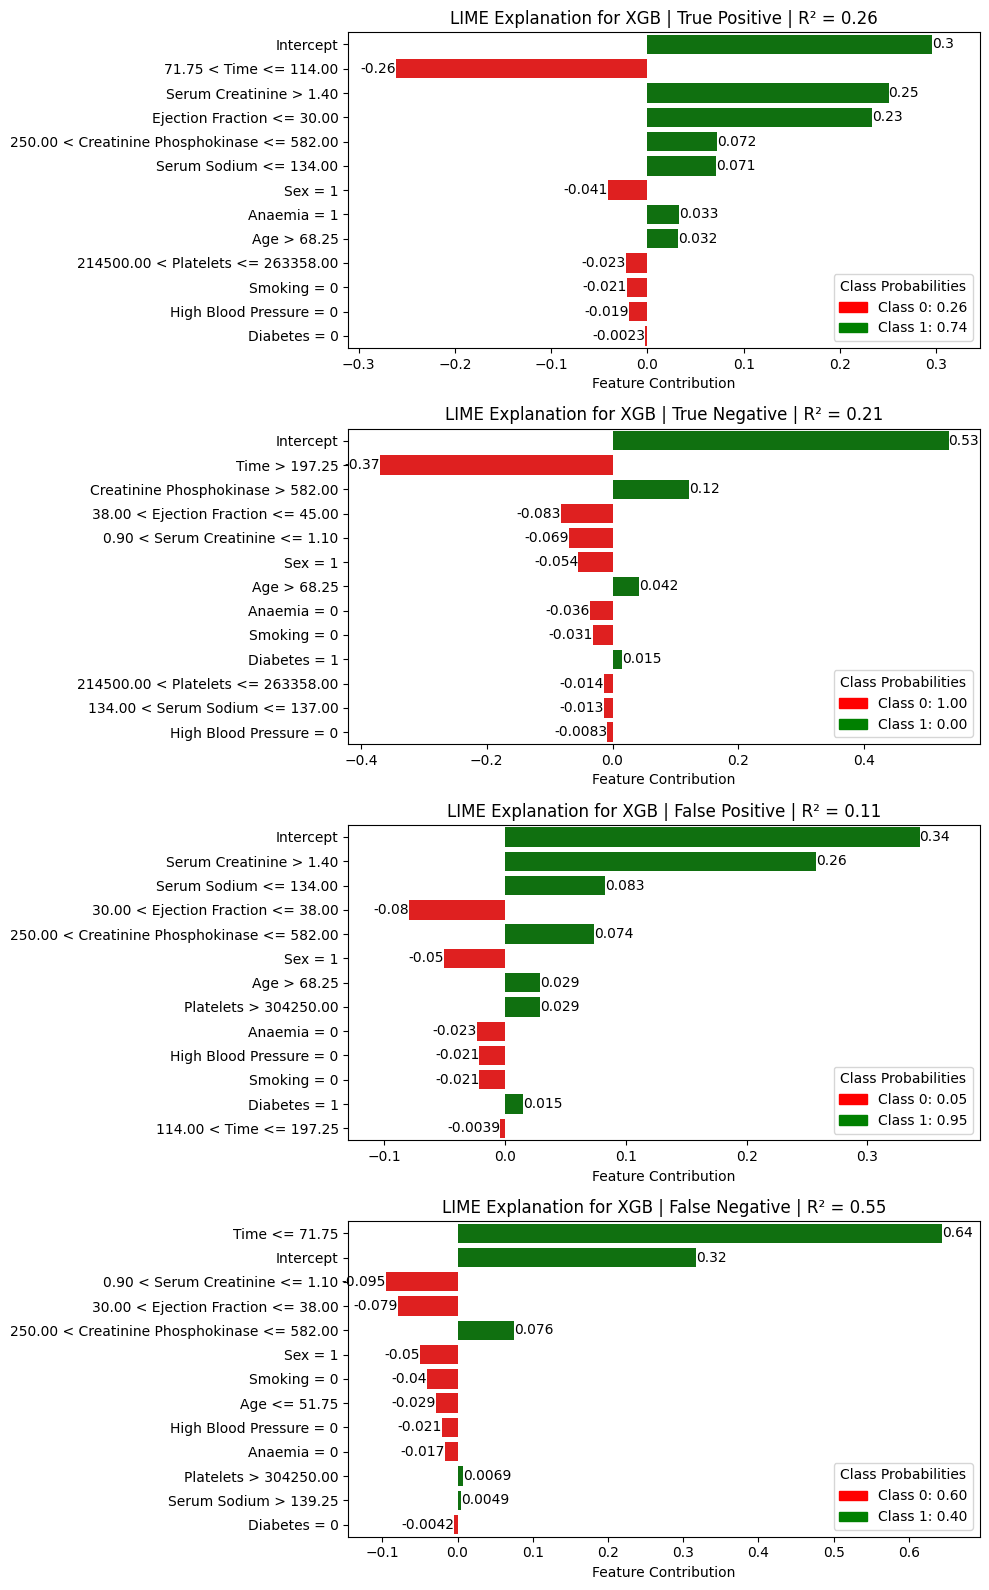

In [37]:
# LIME explanations for local predictions on XGBoost
plot_local_lime_explanations(
    model_type = 'xgb',
    model_dir = model_dir,
    X_train = X_train_decoded,
    X_test = X_test_decoded,
    model_idx = xgb_idx,
    categorical_features = [7, 8, 9, 10, 11]
);

The False Positive is influenced by low Ejection Fraction, high Serum Creatinine, low Serum Sodium (although notably close to normal levels), and advanced Age. The False Negative is likely influenced by low Serum Creatinine and Age, despite higher Serum Sodium and low Time values. It is worth remembering that the LIME explanations may not be trustworthy due to poor local fit.

In [38]:
# X_test feature values for XGBoost indices
X_test_decoded.iloc[xgb_idx]

,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,time,anaemia,diabetes,high_blood_pressure,sex,smoking
73,75,582,30,225000,1.83,134,113,1,0,0,1,0
4,70,2695,40,241000,1.00,137,247,0,1,0,1,0
53,80,582,35,350000,2.10,134,174,0,1,0,1,0
61,45,582,35,385000,1.00,145,61,0,0,0,1,0


The XGBoost model was fairly confident on the selected predictions except for the False Negative.

In [39]:
# Predictions for XGBoost indices
predictions.iloc[xgb_idx]

,logreg-predictions,logreg-probabilities,dt-predictions,dt-probabilities,rf-predictions,rf-probabilities,xgb-predictions,xgb-probabilities,ground_truth
73,0,0.436030,1,0.631579,0,0.484976,1,0.735139,1
4,0,0.050647,0,0.100000,0,0.110567,0,0.002562,0
53,0,0.234406,1,0.631579,0,0.427638,1,0.948071,0
61,0,0.467172,1,0.866667,1,0.505619,0,0.398296,1


## SHAP XGBoost

SHapley Additive exPlanations (SHAP) are a local explainability technique that is based in game theory to explain the output of any black-box machine learning model. SHAP is especially useful for model explainability because it produces an additive model: the sum of all SHAP values for each feature exactly equals the final prediction which is locally consistent with the actual model prediction. This makes it simple to track how each feature affects a prediction, requiring only simple addition of the SHAP values provided without reference to the original dataset. It is important to note that SHAP values indicate how each feature influences the prediction away from the *average* model prediction, not from the middle point of class uncertainty.

Because SHAP values are additive and use the full dataset to get the average model prediction used as the baseline prediction, SHAP can be extended to approximate the global black-box model without requiring any knowledge of the model itself. This greatly increases the amount of analysis capable using SHAP and makes SHAP far more useful than LIME as a technique.

In [40]:
# Load XGBoost model
xgb = load_object('../models/xgb.pickle.xz')

# Create explainer and explanations for full test set
explainer = shap.TreeExplainer(xgb)
shap_values = explainer(X_test)

# Replace the data with the decoded values for visualization purposes
shap_values.data = X_test_decoded.values

# Change feature names to title case for clarity
shap_values.feature_names = [s.replace('_', ' ').title() for s in X_test.columns.tolist()]

Successfully loaded object from ../models/xgb.pickle.xz


The following beeswarm plot shows the spread of local SHAP predictions for each feature.

The following features lead to an increase in risk of death as they increase:
- Serum Creatinine
- Creatinine Phosphokinase
- Age
- Presence of Anaemia, Smoking, High Blood Pressure, or Diabetes

The following features lead to an increase in risk of death as they decrease:
- Time
- Ejection Fraction
- Serum Sodium
- Platelets

These are all expected and make sense from EDA and domain knowledge.

The only slightly puzzling features are Serum Sodium and Platelets, as both features are good in moderation but should be bad at either extreme.

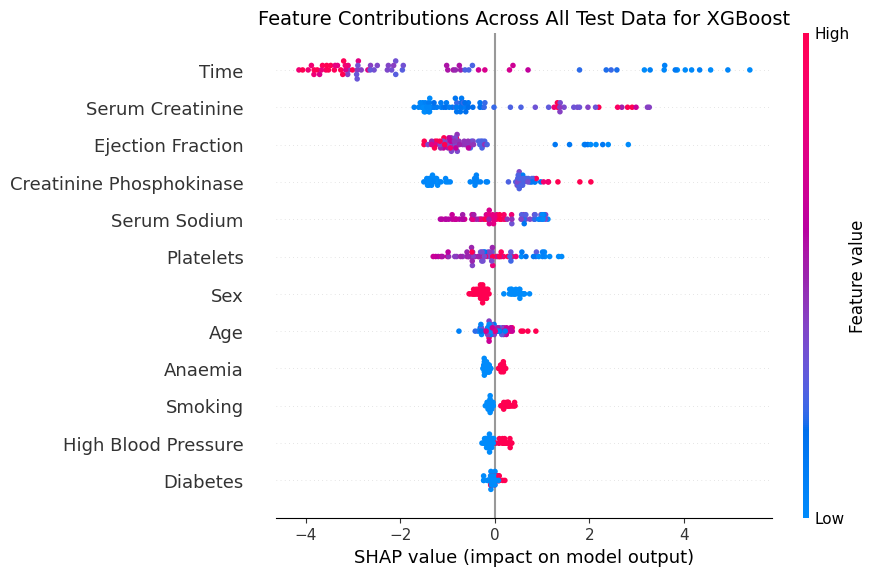

In [41]:
# Create beeswarm plot to view feature contributions across all test data for XGBoost
ax = shap.plots.beeswarm(shap_values, max_display = 12, show = False)
ax.set_title('Feature Contributions Across All Test Data for XGBoost', fontsize = 14);
plt.show();

The following bar plot shows the global approximation of the XGBoost function by SHAP, where the mean absolute SHAP value for each feature can be viewed as being similar to a global feature importance. As expected from prior analysis, Time is the most important feature, with Serum Creatinine and Ejection Fraction following. Surprisingly, Creatinine Phosphokinase has more importance under SHAP than from other explainers. The categorical variables have far lower importance than the numeric variables.

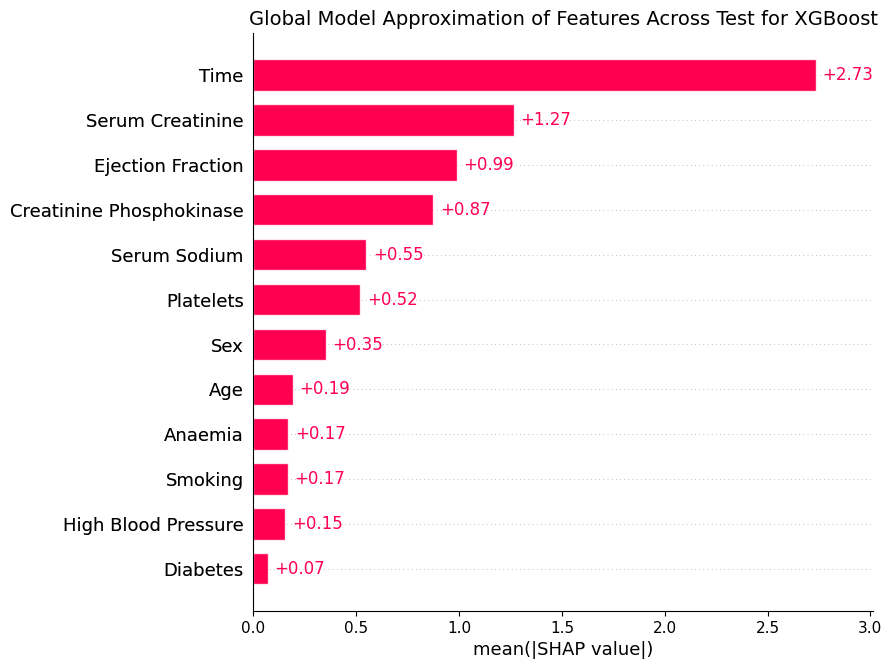

In [42]:
# Bar plot of global SHAP values
ax = shap.plots.bar(shap_values, max_display = 12, show = False)
ax.set_title('Global Model Approximation of Features Across Test for XGBoost', fontsize = 14);
plt.show();

The following two plots contain the same information for the True Positive prediction, showing how each feature adds to the base prediction to get the final prediction. The base prediction for the XGBoost model is -0.555, indicating that the XGBoost is slightly more likely to predict class 0 on average, which is to be expected as it is the majority class.

The high Serum Creatinine is the main contributor to the positive class prediction, along with low Serum Sodium and slightly low Creatinine Phosphokinase. The long Time to follow-up pushes the prediction towards the negative class, but it is not enough to outweigh the other factors.

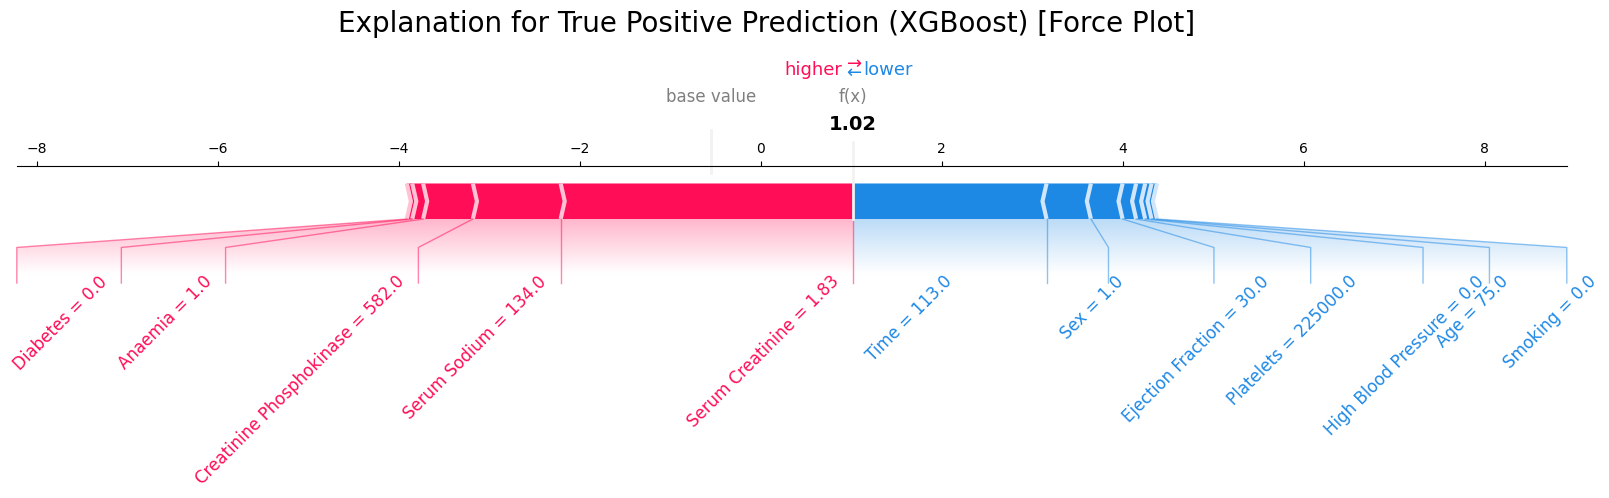

In [43]:
# Force plot for True Positive on XGBoost
shap_force_plot(
    shap_values = shap_values,
    X = X_test_decoded,
    idx = xgb_idx[0],
    model_name = 'XGBoost',
    prediction_label = 'True Positive'
);
plt.show()

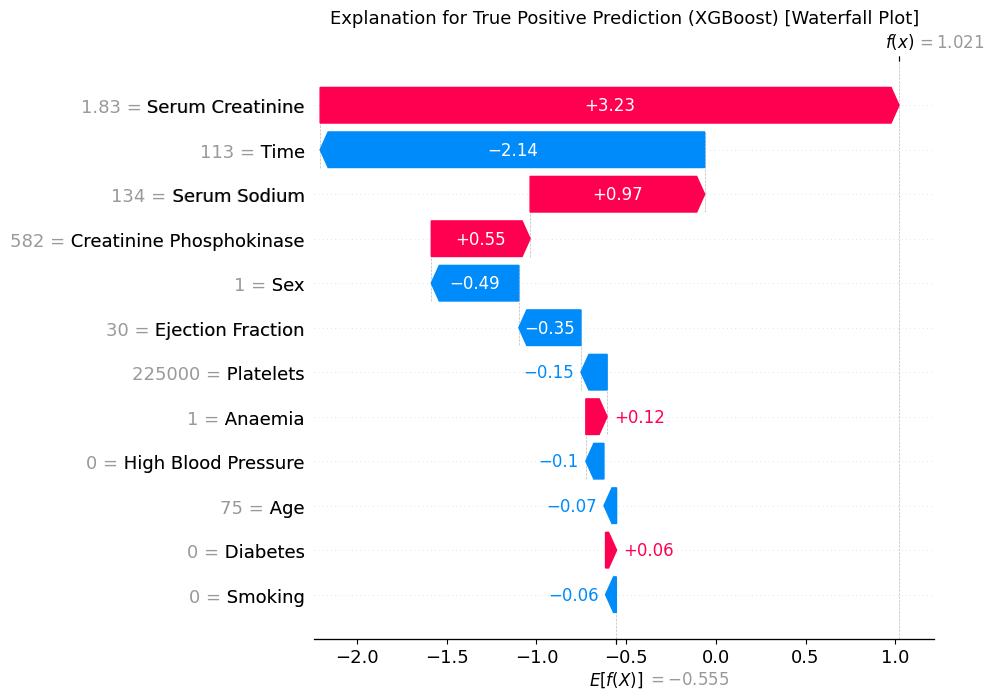

In [44]:
# Waterfall plot for True Positive on XGBoost
shap_waterfall_plot(
    shap_values = shap_values,
    idx = xgb_idx[0],
    model_name = 'XGBoost',
    prediction_label = 'True Positive'
);
plt.show()

For the True Negative prediction, the SHAP explanations are confident that the prediction is actually negative. The high Time value, low Serum Sodium, above average Ejection Fraction (notably still below that of a normal healthy heart), and low Serum Creatinine all point to a healthy patient, despite high Creatinine Phosphokinase.

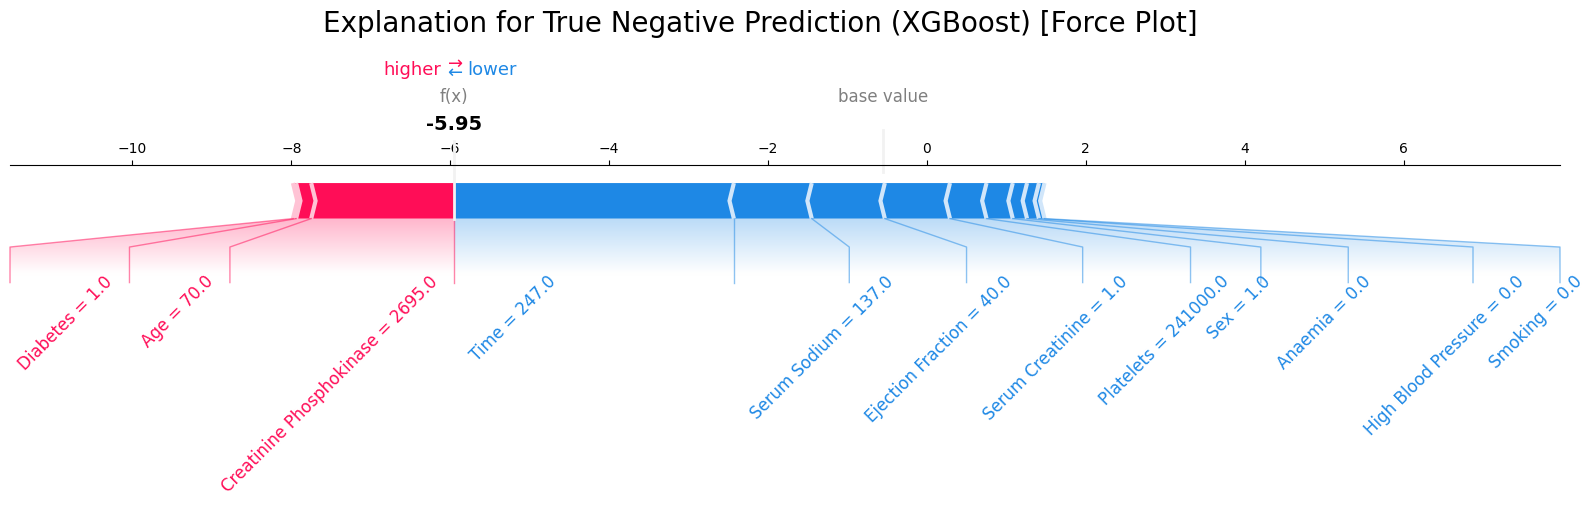

In [45]:
# Force plot for True Negative on XGBoost
shap_force_plot(
    shap_values = shap_values,
    X = X_test_decoded,
    idx = xgb_idx[1],
    model_name = 'XGBoost',
    prediction_label = 'True Negative'
);
plt.show()

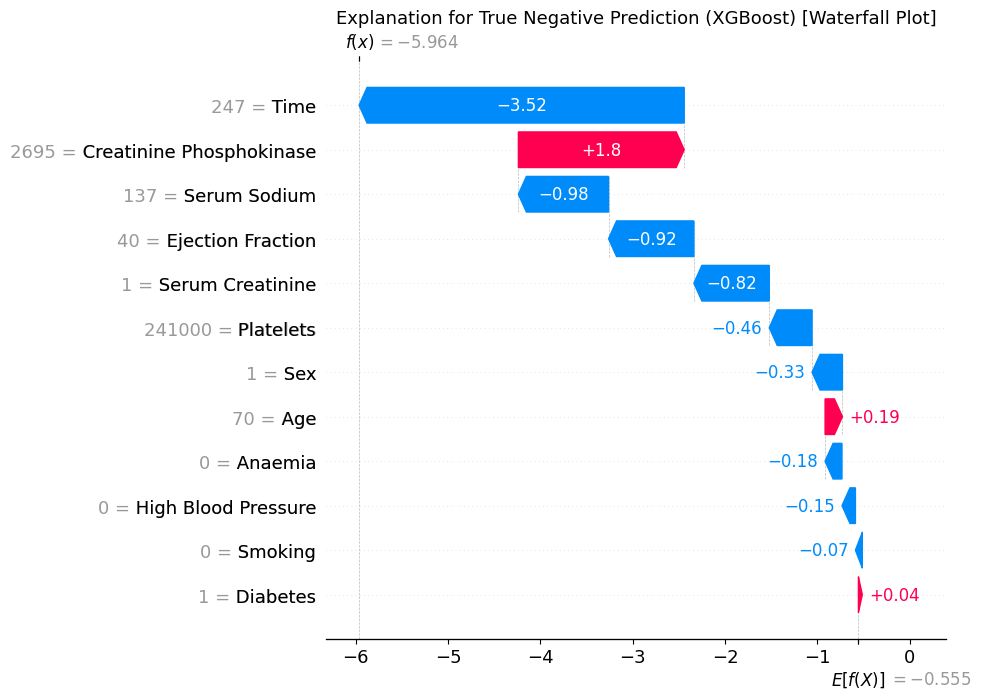

In [46]:
# Waterfall plot for True Negative on XGBoost
shap_waterfall_plot(
    shap_values = shap_values,
    idx = xgb_idx[1],
    model_name = 'XGBoost',
    prediction_label = 'True Negative'
);
plt.show()

For the False Positive Prediction, many factors push the prediction towards the positive class. High Serum Creatinine, low Serum Sodium, low Time, the presence of Diabetes, high Age, and average Creatinine Phosphokinase all point towards high heart risk. The main contributor against positive class prediction is the Ejection Fraction value being only slightly below average (still far below the normal range for a healthy heart).

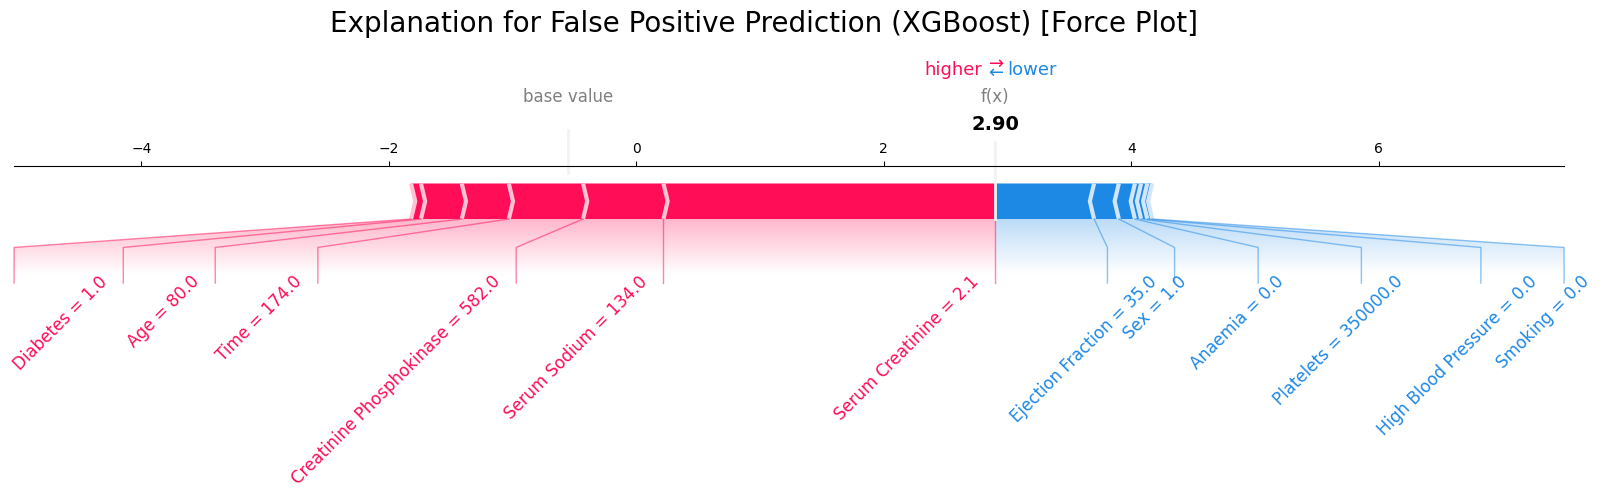

In [47]:
# Force plot for False Positive on XGBoost
shap_force_plot(
    shap_values = shap_values,
    X = X_test_decoded,
    idx = xgb_idx[2],
    model_name = 'XGBoost',
    prediction_label = 'False Positive'
);
plt.show()

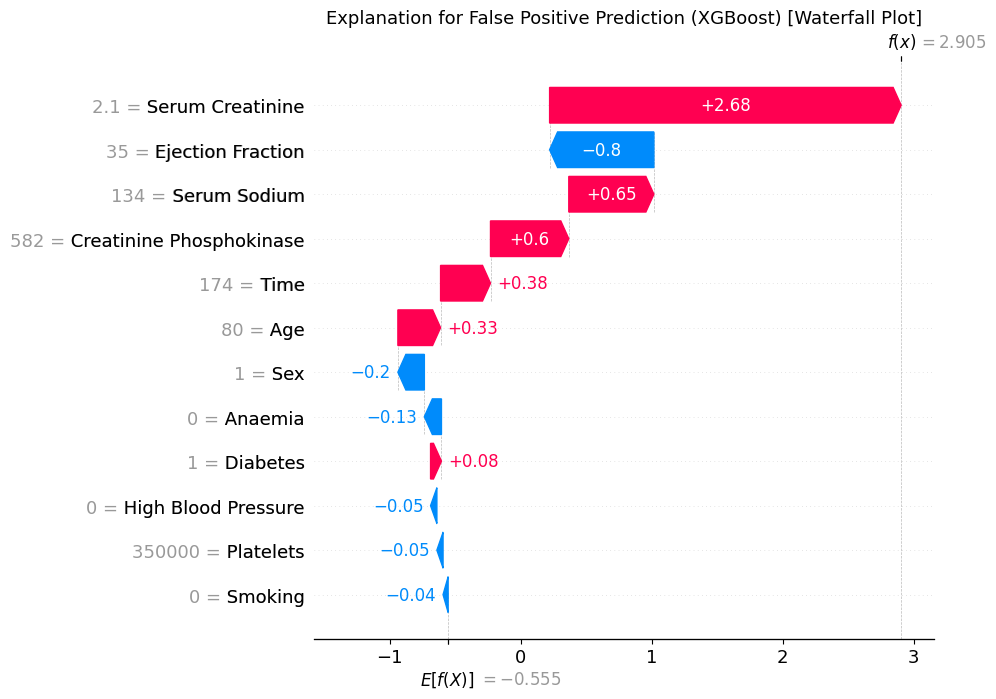

In [48]:
# Waterfall plot for False Positive on XGBoost
shap_waterfall_plot(
    shap_values = shap_values,
    idx = xgb_idx[2],
    model_name = 'XGBoost',
    prediction_label = 'False Positive'
);
plt.show()

It should be noted that the False Negative prediction is only barely categorized as belonging to the negative class. The low Time to follow up pushes the prediction significantly towards heart risk, but the young Age, low Serum Creatinine, lack of other health conditions, and moderate Ejection Fraction (still below the normal range for a healthy heart) all point towards a healthy heart, even in the presence of an average amount of Creatinine Phosphokinase.

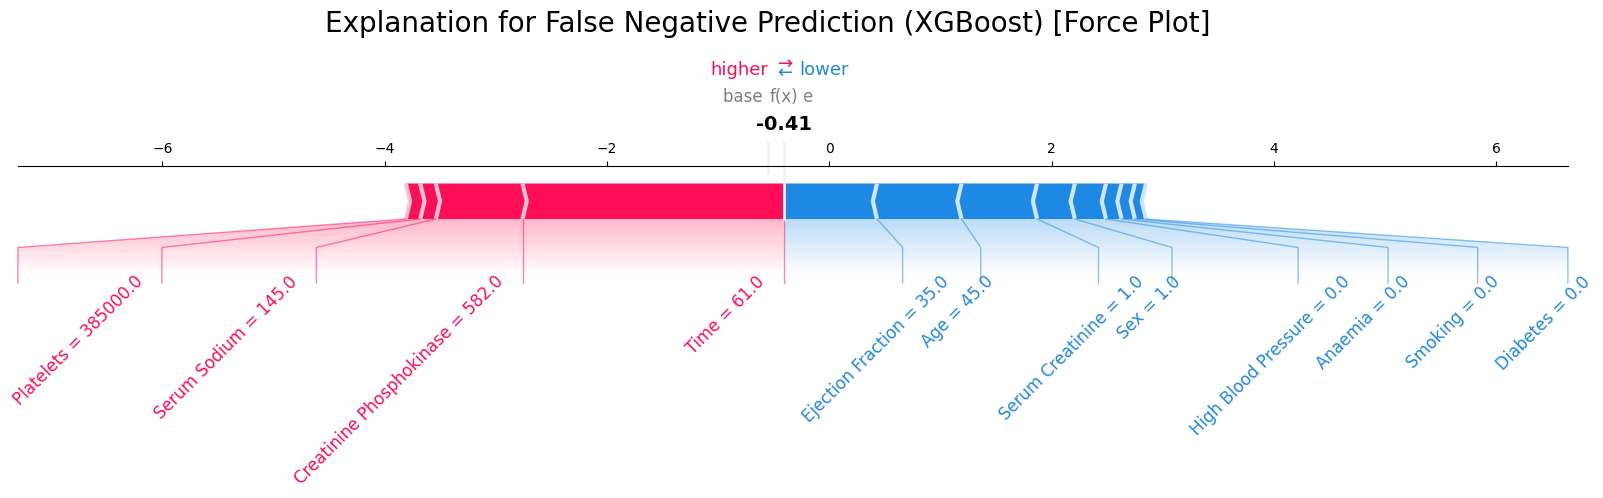

In [49]:
# Force plot for False Negative on XGBoost
shap_force_plot(
    shap_values = shap_values,
    X = X_test_decoded,
    idx = xgb_idx[3],
    model_name = 'XGBoost',
    prediction_label = 'False Negative'
);
plt.show()

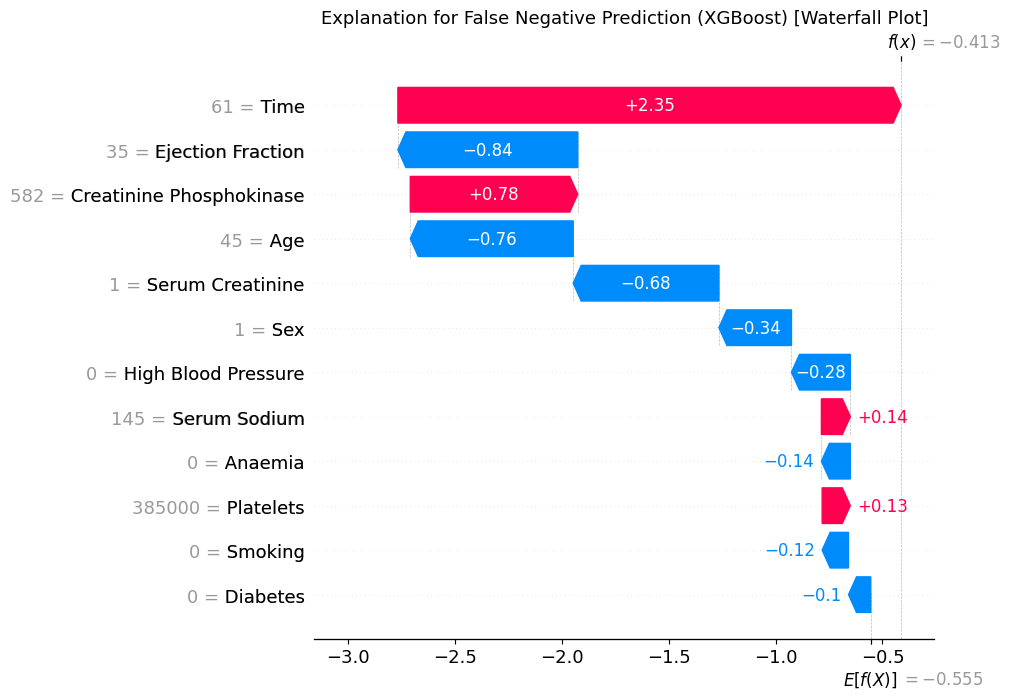

In [50]:
# Waterfall plot for False Negative on XGBoost
shap_waterfall_plot(
    shap_values = shap_values,
    idx = xgb_idx[3],
    model_name = 'XGBoost',
    prediction_label = 'False Negative'
);
plt.show()

## Combined Analysis on Observations

Remember that probabilities $\gt 0.5$ lead to predicting patient death and probabilities $\leq 0.5$ lead to predicting patient survival. This means that probabilities closer to 0 indicate greater confidence in patient survival and probabilities closer to 1 indicate greater confidence in patient death, with probabilities near 0.5 indicating uncertainty.

The Decision Tree tends to be very overconfident in its predictions, despite having the worst metrics of all of the models. The Random Forest has a tendency to have low confidence in its predictions, as the votes from each tree are averaged and the group of trees does not always come to a clear consensus. This is good when the Random Forest is wrong, because it is not confident that it is wrong, but it is bad when the Random Forest is right, as it is not confident in its predictions.

The XGBoost tends to be quite confident in its predictions, as the boosting nature of the model means that successive learners are good at covering for the shortcomings of preceeding learners. Unlike the Decision Tree, the XGBoost has high performance, so the high confidence is a benefit and not a drawback.

The Logistic Regression falls in between in terms of confidence. Sometimes it has high confidence and sometimes it has low confidence. Because the Logistic Regression is the model with the highest bias and lowest complexity, it cannot capture complex relationships and fails to be overconfident or underconfident.

In [51]:
# Combined indices for prediction analysis
combined_idx = list(set(logreg_idx + dt_idx + rf_idx + xgb_idx))
predictions.iloc[combined_idx]

,logreg-predictions,logreg-probabilities,dt-predictions,dt-probabilities,rf-predictions,rf-probabilities,xgb-predictions,xgb-probabilities,ground_truth
3,1,0.764429,1,0.631579,0,0.399150,0,0.396919,0
4,0,0.050647,0,0.100000,0,0.110567,0,0.002562,0
68,0,0.131443,0,0.312500,0,0.306255,0,0.013380,1
5,0,0.216569,0,0.000000,0,0.181509,0,0.001694,1
73,0,0.436030,1,0.631579,0,0.484976,1,0.735139,1
11,1,0.721291,1,1.000000,1,0.644077,1,0.840203,1
19,0,0.486903,1,0.866667,0,0.492904,0,0.123318,0
53,0,0.234406,1,0.631579,0,0.427638,1,0.948071,0
57,1,0.742143,0,0.500000,1,0.614522,1,0.903632,0
61,0,0.467172,1,0.866667,1,0.505619,0,0.398296,1


# Conclusions

All of the models had high focus on the Time feature, representing the follow-up period. It is reasonable to assume that a doctor would prescribe a short follow-up time in the case of high heart risk, indicating that the Time variable is a proxy for general heart health; however, when viewed from a scientific perspective, this feature is not a direct biological or lifetstyle indicator. From this point of view, it is odd that Time was valued so highly by all of the models, and it is easy to imagine a version of the data where Time has no correlation to heart risk, as some patients may refuse to schedule follow-up appointments even if needed for external reasons such as lack of insurance or financial ability to affford appointments. It may be useful to repeat this experiment by dropping the Time feature and to see how the results change.

Some of the features were heavily skewed because the dataset was comprised solely of patients at risk of heart failure. Certain indicators were misinterpreted by the models. For example, Serum Sodium was often treated as a poor factor despite often falling within the suggested range of 135-145 mEq/L. Ejection Fraction was similarly misclassified, where Ejection Fractions <40% were considered strong when the suggested range for a healthy heart is 50-70%. These problems showcase the importance of proper data collection and model interpretation. The models trained on this data became practiced at identifying "slightly unhealthy" vs. "very unhealthy" patients, not between "healthy" and "unhealthy" patients.

The XGBoost and Random Forest models had the best performance on the test set. However, these models are more complex and less interpretable than the glass-box Logistic Regression and Decision Tree models. This highlights the trade-off between model performance and innate model interpretability. The XGBoost was the best model in terms of performance metrics and confidence in predictions.

The ELI5 library showcased the usefulness of glass-box models by being able to directly use model coefficients or tree structure. We know these predictions are fully locally accurate because they can be calculated using the models themselves. The LIME library provides a surrogate linear model at each prediction point for a locally interpretable model. However, LIME surrogates can be hard to trust since the surrogate linear model is created using perturbation of features within a local neighborhood, and the surrogate models are highly sensitive to the definition of "local neighborhood". For both the Random Forest and XGBoost, LIME often failed to produce reliable surrogate models, even if the explanations seemed intuitively reasonable.

SHAP is by far the superior explainability technique for black-box models. Since SHAP creates an additive model, feature explanations are extremely intuitive and directly calculable to see how the features are used to arrive at the local prediction, unlike LIME's method which requires far more math. SHAP can also be used to approximate the global model and view the data at varying levels of granularity, an aspect missing from LIME. The SHAP package comes with many visualizations to do extensive model explainability analysis, and while the inner mechanics of how Shapley values are calculated is complex, the interpretation of SHAP graphs is simple.